# Text-to-SQL Report Visualizations

This notebook loads the saved training and evaluation artifacts from `reports/` and produces plots you can use in the final report.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
REPORTS_DIR = Path('reports')
TRAINING_DIR = REPORTS_DIR / 'training'
EVALUATION_DIR = REPORTS_DIR / 'evaluation'

In [2]:
def latest_run_dir(base_dir: Path) -> Path:
    runs = sorted([path for path in base_dir.iterdir() if path.is_dir()])
    if not runs:
        raise FileNotFoundError(f'No runs found in {base_dir}')
    return runs[-1]

training_run = latest_run_dir(TRAINING_DIR)
evaluation_run = latest_run_dir(EVALUATION_DIR)

print('Latest training run:', training_run)
print('Latest evaluation run:', evaluation_run)

Latest training run: reports/training/20260419_073300
Latest evaluation run: reports/evaluation/20260420_180308


In [3]:
with open(training_run / 'epoch_metrics.json', 'r', encoding='utf-8') as handle:
    epoch_metrics = json.load(handle)

epoch_df = pd.DataFrame(epoch_metrics)
epoch_df

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.3414,1.326350,0.000193,0.1,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0119,1.407939,0.000187,0.2,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.4291,1.237666,0.000180,0.3,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2221,1.590692,0.000173,0.4,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.1384,1.455927,0.000167,0.5,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0862,1.429433,0.000160,0.6,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.0377,1.130754,0.000153,0.7,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.0043,1.281215,0.000147,0.8,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.0125,1.089394,0.000140,0.9,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.0006,1.055754,0.000133,1.0,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


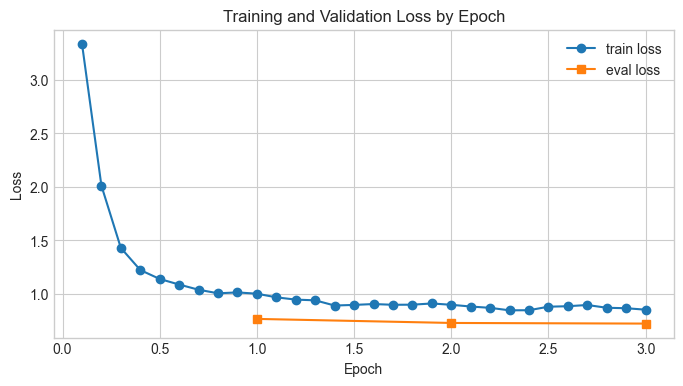

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

if 'loss' in epoch_df.columns:
    train_loss_df = epoch_df.dropna(subset=['loss'])
    if not train_loss_df.empty:
        ax.plot(train_loss_df['epoch'], train_loss_df['loss'], marker='o', label='train loss')

if 'eval_loss' in epoch_df.columns:
    eval_loss_df = epoch_df.dropna(subset=['eval_loss'])
    if not eval_loss_df.empty:
        ax.plot(eval_loss_df['epoch'], eval_loss_df['eval_loss'], marker='s', label='eval loss')

ax.set_title('Training and Validation Loss by Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

In [5]:
summary_df = pd.read_csv(evaluation_run / 'summary.csv')
summary_df.head()

,run_label,temperature,mode,validity,exact_match,aggregation_acc,select_column_acc,table_name_acc,where_column_acc,where_operator_acc,where_value_acc,num_examples
0,final,0.0,base,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100
1,final,0.0,fine_tuned,0.72,0.29,0.81,0.79,0.83,0.62,0.91,0.66,100
2,final,0.0,base_constrained,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100
3,final,0.0,fine_tuned_constrained,0.59,0.15,0.48,0.53,0.60,0.37,0.56,0.31,100
4,final,0.3,base,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100


In [6]:
final_df = summary_df[summary_df['run_label'] == 'final'].copy()
final_pivot = final_df.pivot(index='temperature', columns='mode', values='validity').sort_index()
final_pivot

mode,base,base_constrained,fine_tuned,fine_tuned_constrained
temperature,,,,
0.0,0.0,0.0,0.72,0.59
0.3,0.0,0.0,0.67,0.59
0.7,0.0,0.0,0.54,0.59
1.0,0.0,0.0,0.39,0.56


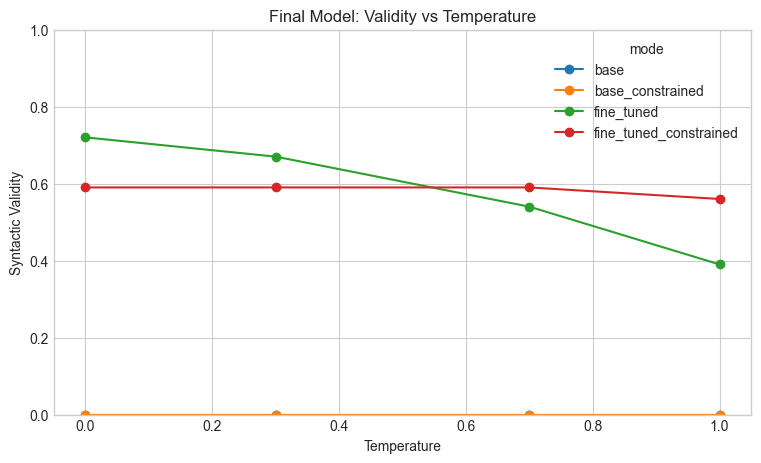

In [7]:
ax = final_pivot.plot(marker='o', figsize=(9, 5))
ax.set_title('Final Model: Validity vs Temperature')
ax.set_xlabel('Temperature')
ax.set_ylabel('Syntactic Validity')
ax.set_ylim(0, 1)
plt.show()

In [8]:
checkpoint_df = summary_df[summary_df['run_label'].str.startswith('checkpoint-')].copy()
checkpoint_df['checkpoint_step'] = checkpoint_df['run_label'].str.extract(r'(\d+)').astype(int)
checkpoint_df['epoch_like'] = checkpoint_df.groupby('run_label')['checkpoint_step'].transform('first').rank(method='dense').astype(int)
checkpoint_df.head()

,run_label,temperature,mode,validity,exact_match,aggregation_acc,select_column_acc,table_name_acc,where_column_acc,where_operator_acc,where_value_acc,num_examples,checkpoint_step,epoch_like
16,checkpoint-500,0.0,base,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100,500,1
17,checkpoint-500,0.0,checkpoint-500,0.59,0.15,0.77,0.71,0.73,0.54,0.93,0.63,100,500,1
18,checkpoint-500,0.0,base_constrained,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100,500,1
19,checkpoint-500,0.0,checkpoint-500_constrained,0.58,0.09,0.44,0.49,0.59,0.33,0.58,0.31,100,500,1
20,checkpoint-500,0.3,base,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100,500,1


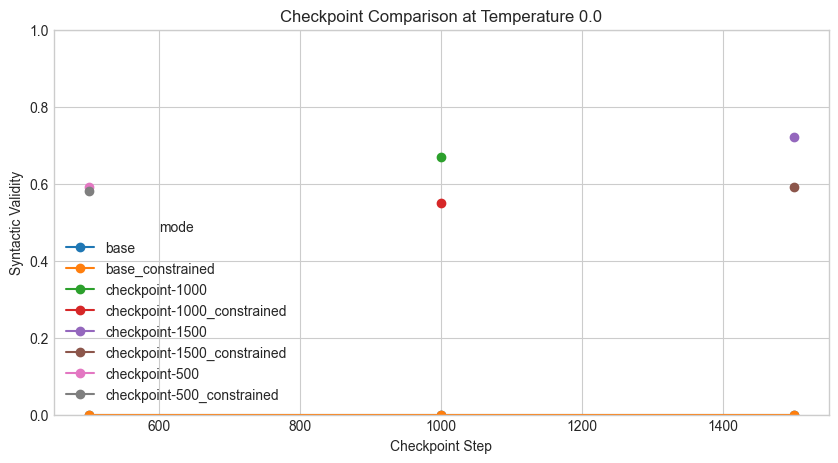

In [9]:
temperature_to_plot = 0.0
checkpoint_plot_df = checkpoint_df[checkpoint_df['temperature'] == temperature_to_plot]
pivot_df = checkpoint_plot_df.pivot(index='checkpoint_step', columns='mode', values='validity').sort_index()
ax = pivot_df.plot(marker='o', figsize=(10, 5))
ax.set_title(f'Checkpoint Comparison at Temperature {temperature_to_plot}')
ax.set_xlabel('Checkpoint Step')
ax.set_ylabel('Syntactic Validity')
ax.set_ylim(0, 1)
plt.show()

In [10]:
samples_df = pd.read_csv(evaluation_run / 'samples.csv')
samples_df.head(12)

,run_label,temperature,sample_index,mode,question,prompt,gold,prediction,is_valid
0,final,0.0,0,base,What is terrence ross' nationality,Translate question to SQL. Question: What is t...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,Query: What is Terrence Ross' nationality Tabl...,False
1,final,0.0,0,fine_tuned,What is terrence ross' nationality,Translate question to SQL. Question: What is t...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,True
2,final,0.0,0,base_constrained,What is terrence ross' nationality,Translate question to SQL. Question: What is t...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,SELECT SU,False
3,final,0.0,0,fine_tuned_constrained,What is terrence ross' nationality,Translate question to SQL. Question: What is t...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,SELECT Nationality FROM 1-10015132-16 WHERE Pl...,False
4,final,0.0,1,base,What clu was in toronto 1995-96,Translate question to SQL. Question: What clu ...,SELECT School/Club Team FROM 1-10015132-16 WHE...,What clu was in toronto 1995-96 Table: 1-10015...,False
5,final,0.0,1,fine_tuned,What clu was in toronto 1995-96,Translate question to SQL. Question: What clu ...,SELECT School/Club Team FROM 1-10015132-16 WHE...,SELECT Years in Toronto FROM 1-10015132-16 WHE...,True
6,final,0.0,1,base_constrained,What clu was in toronto 1995-96,Translate question to SQL. Question: What clu ...,SELECT School/Club Team FROM 1-10015132-16 WHE...,SELECT SU,False
7,final,0.0,1,fine_tuned_constrained,What clu was in toronto 1995-96,Translate question to SQL. Question: What clu ...,SELECT School/Club Team FROM 1-10015132-16 WHE...,SELECT Years in Toronto FROM 1-10015132-16 WHE...,True
8,final,0.0,2,base,which club was in toronto 2003-06,Translate question to SQL. Question: which clu...,SELECT School/Club Team FROM 1-10015132-16 WHE...,WHICH CLUB WAS IN TORONTO 2003-06 Table: 1-100...,False
9,final,0.0,2,fine_tuned,which club was in toronto 2003-06,Translate question to SQL. Question: which clu...,SELECT School/Club Team FROM 1-10015132-16 WHE...,SELECT School/Club Team FROM 1-10015132-16 WHE...,True


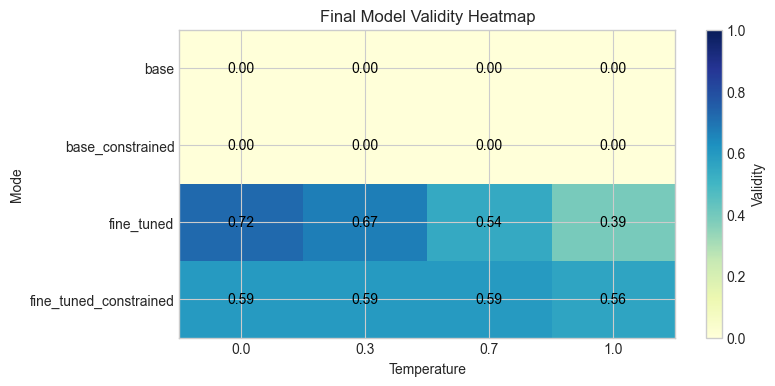

In [11]:
heatmap_df = final_pivot.T.copy()

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_df.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title('Final Model Validity Heatmap')
ax.set_xlabel('Temperature')
ax.set_ylabel('Mode')

for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        ax.text(col_idx, row_idx, f"{heatmap_df.iloc[row_idx, col_idx]:.2f}", ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, label='Validity')
plt.show()

In [12]:
best_setting_df = final_df.loc[final_df.groupby('mode')['validity'].idxmax()].copy()
best_setting_df = best_setting_df.sort_values('validity', ascending=False)
best_setting_df

,run_label,temperature,mode,validity,exact_match,aggregation_acc,select_column_acc,table_name_acc,where_column_acc,where_operator_acc,where_value_acc,num_examples
1,final,0.0,fine_tuned,0.72,0.29,0.81,0.79,0.83,0.62,0.91,0.66,100
3,final,0.0,fine_tuned_constrained,0.59,0.15,0.48,0.53,0.60,0.37,0.56,0.31,100
0,final,0.0,base,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100
2,final,0.0,base_constrained,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100


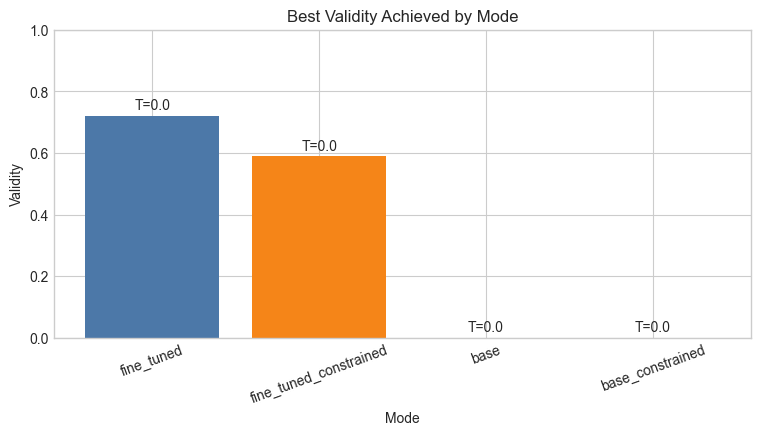

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(best_setting_df['mode'], best_setting_df['validity'], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
ax.set_title('Best Validity Achieved by Mode')
ax.set_xlabel('Mode')
ax.set_ylabel('Validity')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)

for bar, temp in zip(bars, best_setting_df['temperature']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'T={temp}', ha='center')

plt.show()

In [14]:
checkpoint_only_df = checkpoint_df[checkpoint_df['mode'].isin(checkpoint_df['run_label']) | checkpoint_df['mode'].str.endswith('_constrained')].copy()
checkpoint_only_df['mode_group'] = checkpoint_only_df['mode'].replace({r'_constrained$': ' constrained'}, regex=True)
checkpoint_heatmap = checkpoint_only_df.pivot_table(index='checkpoint_step', columns=['mode', 'temperature'], values='validity')
checkpoint_heatmap.head()

mode            base_constrained                checkpoint-1000              \
temperature                  0.0  0.3  0.7  1.0             0.0   0.3   0.7   
checkpoint_step                                                               
500                          0.0  0.0  0.0  0.0             NaN   NaN   NaN   
1000                         0.0  0.0  0.0  0.0            0.67  0.54  0.42   
1500                         0.0  0.0  0.0  0.0             NaN   NaN   NaN   

mode                  checkpoint-1000_constrained        ...  \
temperature       1.0                         0.0   0.3  ...   
checkpoint_step                                          ...   
500               NaN                         NaN   NaN  ...   
1000             0.37                        0.55  0.52  ...   
1500              NaN                         NaN   NaN  ...   

mode            checkpoint-1500_constrained       checkpoint-500              \
temperature                             0.7   1.0            0.0   0.3   0.7   
checkpoint_step                                                                
500                                     NaN   NaN           0.59  0.55  0.42   
1000                                    NaN   NaN            NaN   NaN   NaN   
1500                                   0.55  0.54            NaN   NaN   NaN   

mode                  checkpoint-500_constrained                    
temperature       1.0                        0.0   0.3   0.7   1.0  
checkpoint_step                                                     
500              0.27                       0.58  0.53  0.49  0.49  
1000              NaN                        NaN   NaN   NaN   NaN  
1500              NaN                        NaN   NaN   NaN   NaN  

[3 rows x 28 columns]

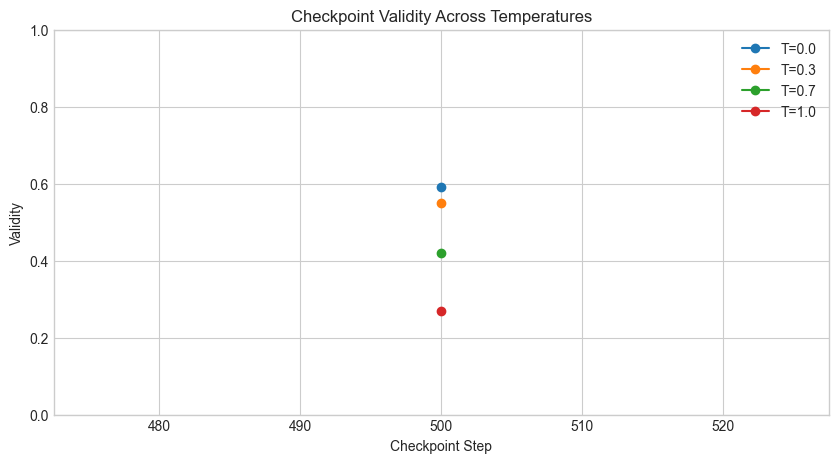

In [15]:
checkpoint_temperature_df = checkpoint_df[checkpoint_df['mode'].isin(['checkpoint-100', 'checkpoint-200', 'checkpoint-300', 'checkpoint-400', 'checkpoint-500'])].copy()
if checkpoint_temperature_df.empty:
    checkpoint_temperature_df = checkpoint_df[~checkpoint_df['mode'].str.contains('base') & ~checkpoint_df['mode'].str.contains('constrained')].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for temperature, temp_df in checkpoint_temperature_df.groupby('temperature'):
    temp_df = temp_df.sort_values('checkpoint_step')
    ax.plot(temp_df['checkpoint_step'], temp_df['validity'], marker='o', label=f'T={temperature}')

ax.set_title('Checkpoint Validity Across Temperatures')
ax.set_xlabel('Checkpoint Step')
ax.set_ylabel('Validity')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

In [16]:
validity_distribution_df = final_df.copy()
validity_distribution_df['invalidity'] = 1 - validity_distribution_df['validity']
distribution_pivot = validity_distribution_df.pivot(index='temperature', columns='mode', values='invalidity').sort_index()
distribution_pivot

mode,base,base_constrained,fine_tuned,fine_tuned_constrained
temperature,,,,
0.0,1.0,1.0,0.28,0.41
0.3,1.0,1.0,0.33,0.41
0.7,1.0,1.0,0.46,0.41
1.0,1.0,1.0,0.61,0.44


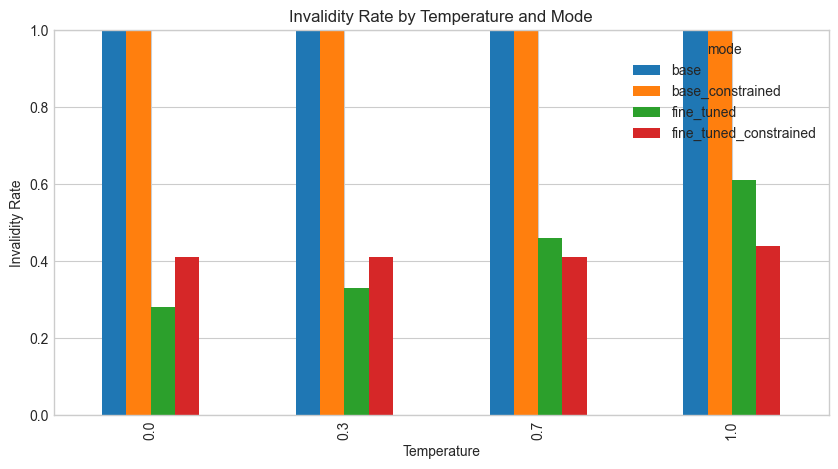

In [17]:
ax = distribution_pivot.plot(kind='bar', stacked=False, figsize=(10, 5))
ax.set_title('Invalidity Rate by Temperature and Mode')
ax.set_xlabel('Temperature')
ax.set_ylabel('Invalidity Rate')
ax.set_ylim(0, 1)
plt.show()

## Suggested Figures for the Report

- Training/validation loss by epoch
- Final-model validity vs temperature
- Final-model validity heatmap across modes and temperatures
- Best validity achieved by each mode
- Checkpoint validity progression at temperature 0.0
- Checkpoint validity across temperatures
- Invalidity-rate comparison by temperature and mode
- Example predictions table from `samples.csv`